# 00 · Verificaciones del dataset

**Objetivo:** Confirmar tamaño, rango real de fechas, rezago de registro, definición de hospitalización, tasa base y calidad de llaves.

> Regla: este notebook cuenta la historia; la lógica pesada vive en `src/dm_hosp/`.

In [1]:
%load_ext autoreload
%autoreload 2
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dm_hosp.config import load_config
from dm_hosp.paths import FIGURES, INTERIM, PROCESSED, TABLES

pd.set_option("display.max_columns", 60, "display.width", 200)
cfg = load_config()
con = duckdb.connect()
con.execute(f"PRAGMA memory_limit='{cfg['datos']['memoria_duckdb']}'")

In [4]:
from dm_hosp.paths import RAW

P = (INTERIM / "prestaciones.parquet").as_posix()
# Esto arregla el formato de fecha que antes nos salía como 1970
FECHA = "try_strptime(CAST(FECHA_ATENCION AS VARCHAR), '%Y%m%d')::DATE"

def q(sql):
    """Ejecuta una consulta SQL en DuckDB y la devuelve como DataFrame de Pandas"""
    return con.execute(sql).df()

## 1. Tamaño, pacientes y rango de fechas

In [5]:
P = INTERIM / 'prestaciones.parquet'
q(f"""
SELECT COUNT(*) AS filas, 
       COUNT(DISTINCT CODIGO_ANONIMIZADO) AS pacientes,
       COUNT(DISTINCT ID_REGISTRO_REL) AS atenciones_unicas,
       MIN({FECHA}) AS desde, 
       MAX({FECHA}) AS hasta,
       COUNT(*) FILTER (WHERE {FECHA} IS NULL) AS fechas_invalidas
FROM read_parquet('{P}')
""")

,filas,pacientes,atenciones_unicas,desde,hasta,fechas_invalidas
0,32249937,1005550,32249937,2022-01-01,2025-12-31,0


## 2. Rezago de registro (atenciones por mes)

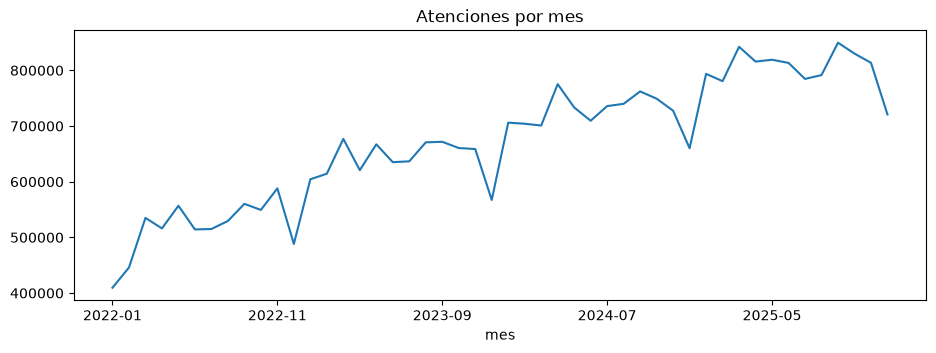

,mes,atenciones
30,2024-07,735789
31,2024-08,739854
32,2024-09,762133
33,2024-10,749101
34,2024-11,727555
35,2024-12,660082
36,2025-01,793699
37,2025-02,780566
38,2025-03,842310
39,2025-04,815746


In [6]:
mes = q(f"""
SELECT strftime({FECHA}, '%Y-%m') AS mes, COUNT(*) AS atenciones
FROM read_parquet('{P}') 
GROUP BY 1 ORDER BY 1
""")

# Graficamos la tendencia
mes.set_index("mes")["atenciones"].plot(figsize=(11, 3.5), title="Atenciones por mes")
plt.show()

# Mostramos los últimos 18 meses en tabla para ver la caída
display(mes.tail(18))

## 3. ¿Cómo identificar una hospitalización?
Cruce `SERVICIO_PRESTACIONAL` × `DIAS_HOSP>0` × `DESTINO_ASEGURADO`.

In [8]:
print("CRUCE 1: SERVICIOS QUE SÍ TIENEN DÍAS DE HOSPITALIZACIÓN")
display(q(f"""
SELECT SERVICIO_PRESTACIONAL, 
       COUNT(*) AS total_atenciones,
       COUNT(*) FILTER (WHERE TRY_CAST(DIAS_HOSP AS DOUBLE) > 0) AS con_dias_hosp
FROM read_parquet('{P}') 
GROUP BY 1 
HAVING con_dias_hosp > 0
ORDER BY 3 DESC
"""))

print("\nCRUCE 2: DESTINOS QUE SÍ TIENEN DÍAS DE HOSPITALIZACIÓN")
display(q(f"""
SELECT DESTINO_ASEGURADO, 
       COUNT(*) AS total_atenciones,
       COUNT(*) FILTER (WHERE TRY_CAST(DIAS_HOSP AS DOUBLE) > 0) AS con_dias_hosp
FROM read_parquet('{P}') 
GROUP BY 1 
HAVING con_dias_hosp > 0
ORDER BY 3 DESC
"""))

CRUCE 1: SERVICIOS QUE SÍ TIENEN DÍAS DE HOSPITALIZACIÓN


,SERVICIO_PRESTACIONAL,total_atenciones,con_dias_hosp
0,INTERNAMIENTO EN EESS SIN INTERVENCIÓN QUIRÚRGICA,256080,256079
1,INTERNAMIENTO CON INTERVENCIÓN QUIRÚRGICA MAYOR,82856,82856
2,INTERNAMIENTO CON ESTANCIA EN LA UNIDAD DE CUI...,25620,25620
3,INTERNAMIENTO CON INTERVENCIÓN QUIRÚRGICA MENOR,17361,17361
4,CESÁREA,14142,14142
5,ATENCIÓN DE PARTO VAGINAL,14087,14087
6,INTERNAMIENTO DEL RN CON PATOLOGÍA NO QUIRURGICA,746,746
7,INTERNAMIENTO CON INTERVENCIÓN QUIRÚRGICA DEL RN,4,4



CRUCE 2: DESTINOS QUE SÍ TIENEN DÍAS DE HOSPITALIZACIÓN


,DESTINO_ASEGURADO,total_atenciones,con_dias_hosp
0,Alta,9984668,288478
1,Contrarreferido,423533,71474
2,Citado,20245503,23877
3,Fallecido,27896,23582
4,Ref. Emergencia,24056,2764
5,Corte Administrativo,372,372
6,Hospitalizado,6736,161
7,Ref. Consulta Externa,331335,138
8,Ref. Apoyo al Diax,24036,49


## 4. Tasa base candidata por año

In [ ]:
# Regla actualizada basada en el EDA
H = "(COALESCE(TRY_CAST(DIAS_HOSP AS DOUBLE), 0) > 0 OR SERVICIO_PRESTACIONAL ILIKE '%INTERNAMIENTO%')"

tasa = q(f"""
WITH a AS (
    SELECT CODIGO_ANONIMIZADO AS pid, 
           {FECHA} AS fecha, 
           ({H}) AS es_hosp
    FROM read_parquet('{P}')
)
SELECT year(fecha) AS anio, 
       COUNT(DISTINCT pid) AS pacientes_totales,
       COUNT(DISTINCT pid) FILTER (WHERE es_hosp) AS pacientes_hospitalizados,
       ROUND(100.0 * COUNT(DISTINCT pid) FILTER (WHERE es_hosp) / COUNT(DISTINCT pid), 2) AS tasa_pct
FROM a 
GROUP BY 1 
ORDER BY 1
""")

display(tasa)

,anio,pacientes_totales,pacientes_hospitalizados,tasa_pct
0,2022,694362,68973,9.93
1,2023,737698,76365,10.35
2,2024,757312,81327,10.74
3,2025,757127,84887,11.21


## 5. Consistencia del historial

In [10]:
print("1. PACIENTES CON MÁS DE UN AÑO DE HISTORIAL (Vital para cohortes)")
display(q(f"""
SELECT COUNT(*) FILTER (WHERE n_anios >= 2) AS con_2_o_mas_anios, 
       COUNT(*) AS total_pacientes,
       ROUND(100.0 * COUNT(*) FILTER (WHERE n_anios >= 2) / COUNT(*), 2) AS pct_con_historial
FROM (
    SELECT CODIGO_ANONIMIZADO, COUNT(DISTINCT year({FECHA})) AS n_anios
    FROM read_parquet('{P}') 
    GROUP BY 1
)
"""))

print("\n2. DISTRIBUCIÓN DE ATENCIONES POR PACIENTE")
display(q(f"""
SELECT quantile_cont(n, [0.1, 0.25, 0.5, 0.75, 0.9, 0.99]) AS cuantiles_atenciones, 
       ROUND(AVG(n), 1) AS media, MAX(n) AS maximo
FROM (SELECT CODIGO_ANONIMIZADO, COUNT(*) AS n FROM read_parquet('{P}') GROUP BY 1)
"""))

1. PACIENTES CON MÁS DE UN AÑO DE HISTORIAL (Vital para cohortes)


,con_2_o_mas_anios,total_pacientes,pct_con_historial
0,846350,1005550,84.17



2. DISTRIBUCIÓN DE ATENCIONES POR PACIENTE


,cuantiles_atenciones,media,maximo
0,"[3.0, 8.0, 21.0, 44.0, 75.0, 161.0]",32.1,2077


## 6. Mapeo de Catálogos Clínicos

In [11]:
CAT = next(RAW.rglob("*.xlsx")) # Busca el archivo 6. Catálogos.xlsx
print(f"Buscando términos clínicos en: {CAT.name}\n")

busquedas = [
    ("Medicamentos", "NOMBRE_MEDICAMENTO", ["insulina", "metformina", "glibenclamida"]),
    ("Procedimientos", "NOMBRE_PROCEDIMIENTO", ["glicosilada", "creatinina", "fondo de ojo"]),
]

for hoja, col, palabras in busquedas:
    cat = pd.read_excel(CAT, sheet_name=hoja, dtype=str)
    for w in palabras:
        hit = cat[cat[col].str.contains(w, case=False, na=False)]
        print(f"[{hoja}] Término '{w}': {len(hit)} coincidencias encontradas.")
        if len(hit) > 0:
            display(hit.head(3))

Buscando términos clínicos en: 6. Catálogos.xlsx

[Medicamentos] Término 'insulina': 39 coincidencias encontradas.


,COD_MEDICAMENTOS,NOMBRE_MEDICAMENTO,PRESENTACIÓN,CONCENTRACIÓN,FORMA FARMACEUTICA
424,27527,INSULINA ASPARTICA,3 mL,100 UI/mL,INY
472,28491,INSULINA DETEMIR,3 mL,100 UI/ mL,INY
3184,04083,INSULINA GLARGINA,5 mL,100 UI/mL,INY


[Medicamentos] Término 'metformina': 14 coincidencias encontradas.


,COD_MEDICAMENTOS,NOMBRE_MEDICAMENTO,PRESENTACIÓN,CONCENTRACIÓN,FORMA FARMACEUTICA
3782,03754,GLIBENCLAMIDA + METFORMINA,NaN,2.5 mg + 400 mg,TAB
3783,03755,GLIBENCLAMIDA + METFORMINA,NaN,2.5 mg + 500 mg,TAB
3784,03756,GLIBENCLAMIDA + METFORMINA,NaN,1.25 mg + 250 mg,TAB


[Medicamentos] Término 'glibenclamida': 6 coincidencias encontradas.


...

,COD_PROCEDIMIENTO,NOMBRE_PROCEDIMIENTO
5489,81512,"Análisis de anormalidades fetales congénitas, ..."


[Procedimientos] Término 'creatinina': 11 coincidencias encontradas.


,COD_PROCEDIMIENTO,NOMBRE_PROCEDIMIENTO
5739,82565,Dosaje de creatinina en sangre
5740,82570,Dosaje de Creatinina; otra fuente
5741,82570.01,Creatinina en orina simple


[Procedimientos] Término 'fondo de ojo': 2 coincidencias encontradas.


,COD_PROCEDIMIENTO,NOMBRE_PROCEDIMIENTO
5992,92250,Fotografía de fondo con interpretación y repor...
5993,92251,Examen y Evaluación de fondo de ojo bajo anest...


## 5. Decisiones
Registrar en `docs/decisiones.md` y ajustar `configs/config.yaml`.